# Лабораторная работа 4: Gaussian Mixture Model

Восстановление плотности на датасете **Wine** (`sklearn.datasets.load_wine`).

- Реализация: `source/gmm.py` (алгоритм EM)
- Эталон: `sklearn.mixture.GaussianMixture`
- Оценка качества: максимизация логарифма правдоподобия, AIC, BIC

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture

ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from source.data import load_dataset
from source.experiment import run_experiments
from source.gmm import GaussianMixtureModel

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Загрузка датасета Wine

In [3]:
X, y, feature_names, target_names = load_dataset(standardize=True)

print(f"Размер выборки: {X.shape[0]} объектов, {X.shape[1]} признаков")
print(f"Классы (для справки): {target_names}")
print(f"Признаки: {feature_names[:5]} ...")

Размер выборки: 178 объектов, 13 признаков
Классы (для справки): [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium'] ...


## 2. Обучение GMM и оценка по логарифму правдоподобия

Принцип максимума правдоподобия: EM-максимизирует $\sum_i \log p(x_i \mid \theta)$.

In [4]:
X, y, results_df = run_experiments(component_range=range(2, 6), random_state=42)

results_df["score_diff"] = results_df["custom_score"] - results_df["sklearn_score"]
results_df["ll_diff"] = results_df["custom_log_likelihood"] - results_df["sklearn_log_likelihood"]
results_df.round(4)

,n_components,custom_score,sklearn_score,custom_log_likelihood,sklearn_log_likelihood,custom_aic,sklearn_aic,custom_bic,sklearn_bic,custom_n_iter,sklearn_n_iter,score_diff,ll_diff
0,2,-13.6907,-12.8418,-2436.9370,-2285.8451,5291.8739,4989.6903,5956.8667,5654.6831,19,42,-0.8488,-151.0918
1,3,-12.0042,-12.2957,-2136.7552,-2188.6381,4901.5104,5005.2762,5900.5905,6004.3562,60,24,0.2915,51.8829
2,4,-11.4832,-11.6973,-2044.0116,-2082.1174,4926.0233,5002.2347,6259.1906,6335.4021,36,21,0.2141,38.1057
3,5,-9.4916,-11.2336,-1689.5063,-1999.5839,4427.0126,5047.1677,6094.2672,6714.4223,37,33,1.7420,310.0776


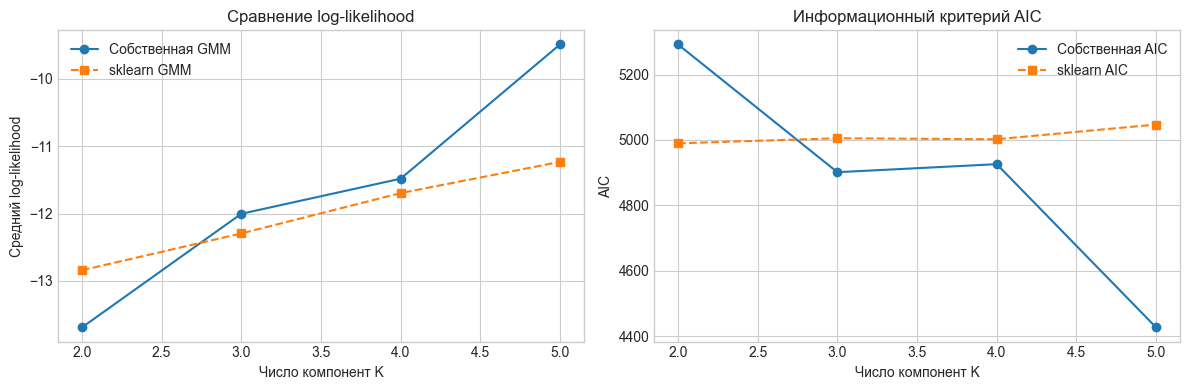

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

k_vals = results_df["n_components"]
axes[0].plot(k_vals, results_df["custom_score"], "o-", label="Собственная GMM")
axes[0].plot(k_vals, results_df["sklearn_score"], "s--", label="sklearn GMM")
axes[0].set_xlabel("Число компонент K")
axes[0].set_ylabel("Средний log-likelihood")
axes[0].set_title("Сравнение log-likelihood")
axes[0].legend()

axes[1].plot(k_vals, results_df["custom_aic"], "o-", label="Собственная AIC")
axes[1].plot(k_vals, results_df["sklearn_aic"], "s--", label="sklearn AIC")
axes[1].set_xlabel("Число компонент K")
axes[1].set_ylabel("AIC")
axes[1].set_title("Информационный критерий AIC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Визуализация кластеров (PCA → 2D)

Для $K=3$ сравниваем кластеры модели с истинными метками сортов винограда.

Adjusted Rand Index (собственная): 0.3775
Adjusted Rand Index (sklearn):       0.3286


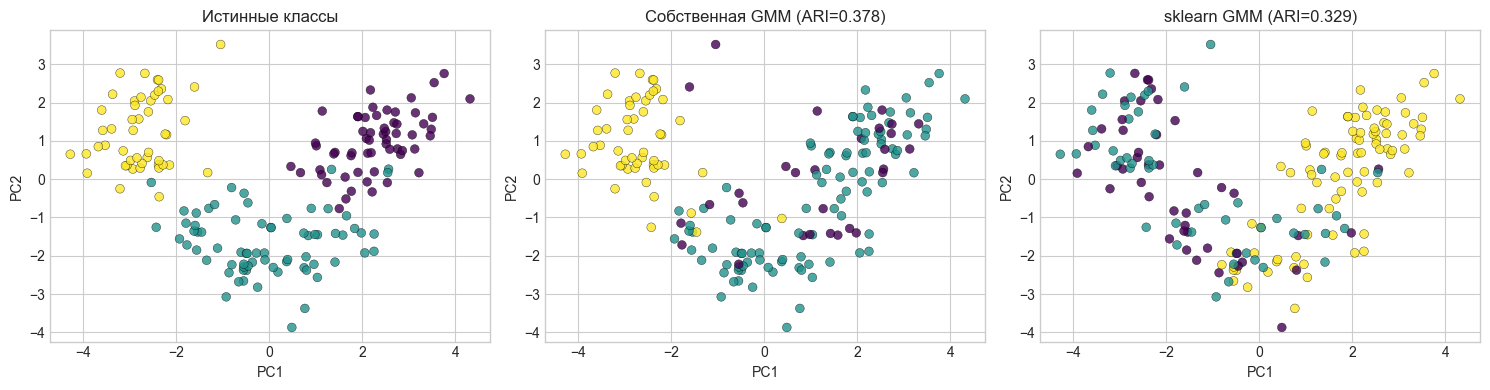

In [6]:
K = 3
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

custom_model = GaussianMixtureModel(n_components=K, random_state=42, max_iter=300).fit(X)
sklearn_model = GaussianMixture(
    n_components=K, random_state=42, max_iter=300, reg_covar=1e-6, init_params="random"
).fit(X)

labels_custom = custom_model.predict(X)
labels_sklearn = sklearn_model.predict(X)

ari_custom = adjusted_rand_score(y, labels_custom)
ari_sklearn = adjusted_rand_score(y, labels_sklearn)
print(f"Adjusted Rand Index (собственная): {ari_custom:.4f}")
print(f"Adjusted Rand Index (sklearn):       {ari_sklearn:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_kw = dict(s=40, alpha=0.8, edgecolors="k", linewidths=0.3)

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="viridis", **scatter_kw)
axes[0].set_title("Истинные классы")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_custom, cmap="viridis", **scatter_kw)
axes[1].set_title(f"Собственная GMM (ARI={ari_custom:.3f})")

axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_sklearn, cmap="viridis", **scatter_kw)
axes[2].set_title(f"sklearn GMM (ARI={ari_sklearn:.3f})")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()